In [ ]:
"""
Hierarchical Document Knowledge Graph (DKG) Builder
====================================================
Architecture: Document → Section/Heading → Paragraph → Entity

Instead of extracting every entity from the entire text in one flat call,
this builds a structured graph that mirrors document hierarchy. The LLM
is only called at the paragraph level for entity extraction, making it
far more efficient and the graph far more navigable for retrieval.

Inspired by:
- Document GraphRAG (2025) — dual DKG/IKG architecture
- LightRAG (2024) — incremental, dual-level retrieval
- PathRAG (2025) — path-based pruning for precision
"""

import os
import re
import json
import hashlib
from dataclasses import dataclass, field
from typing import Optional
from groq import Groq
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from api import api_key

# ─────────────────────────────────────────────
# 1. DATA STRUCTURES
# ─────────────────────────────────────────────

@dataclass
class Paragraph:
    """A single paragraph within a section."""
    id: str
    text: str
    section_id: str
    order: int  # position within section

@dataclass
class Section:
    """A heading/section within a document."""
    id: str
    title: str
    level: int  # heading depth (1 = H1, 2 = H2, etc.)
    doc_id: str
    parent_section_id: Optional[str] = None
    paragraphs: list = field(default_factory=list)

@dataclass
class Document:
    """Top-level document node."""
    id: str
    name: str
    source_path: str
    sections: list = field(default_factory=list)


# ─────────────────────────────────────────────
# 2. DOCUMENT PARSER — Structure Extraction
# ─────────────────────────────────────────────

class DocumentParser:
    """
    Parses raw text into a Document → Section → Paragraph hierarchy.
    
    Supports:
      - Markdown headings (# / ## / ###)
      - Numbered headings (1. / 1.1 / 1.1.1)
      - ALL-CAPS headings (common in German technical docs)
      - Fallback: treats entire text as one section
    """

    # Patterns for heading detection
    MARKDOWN_HEADING = re.compile(r'^(#{1,4})\s+(.+)$', re.MULTILINE)
    NUMBERED_HEADING = re.compile(r'^(\d+(?:\.\d+)*)\s+([A-ZÜÖÄ].{2,80})$', re.MULTILINE)
    ALLCAPS_HEADING  = re.compile(r'^([A-ZÜÖÄ][A-ZÜÖÄ\s\-]{4,80})$', re.MULTILINE)

    @staticmethod
    def _make_id(*parts):
        """Create a deterministic short ID from parts."""
        raw = "|".join(str(p) for p in parts)
        return hashlib.md5(raw.encode()).hexdigest()[:10]

    def parse(self, text: str, doc_name: str = "document", source_path: str = "") -> Document:
        """Parse text into structured Document object."""
        doc_id = self._make_id(doc_name, source_path)
        doc = Document(id=doc_id, name=doc_name, source_path=source_path)

        # Try to detect heading style
        sections = self._split_by_headings(text, doc_id)

        if not sections:
            # Fallback: no headings found — treat as single section
            sec_id = self._make_id(doc_id, "root")
            section = Section(id=sec_id, title=doc_name, level=1, doc_id=doc_id)
            section.paragraphs = self._split_paragraphs(text, sec_id)
            sections = [section]

        doc.sections = sections
        return doc

    def _split_by_headings(self, text: str, doc_id: str) -> list:
        """Detect and split text by headings into Section objects."""
        # Try markdown first
        markers = [(m.start(), len(m.group(1)), m.group(2).strip())
                    for m in self.MARKDOWN_HEADING.finditer(text)]

        # Try numbered headings if no markdown found
        if not markers:
            markers = [(m.start(), m.group(1).count('.') + 1, m.group(2).strip())
                        for m in self.NUMBERED_HEADING.finditer(text)]

        # Try ALL-CAPS headings
        if not markers:
            markers = [(m.start(), 1, m.group(1).strip())
                        for m in self.ALLCAPS_HEADING.finditer(text)
                        if len(m.group(1).strip().split()) <= 8]  # max 8 words

        if not markers:
            return []

        sections = []
        section_stack = {}  # level -> section_id for parent tracking

        for i, (pos, level, title) in enumerate(markers):
            # Extract text between this heading and the next
            start = pos + len(title) + level + 1  # skip heading line
            end = markers[i + 1][0] if i + 1 < len(markers) else len(text)
            body = text[start:end].strip()

            sec_id = self._make_id(doc_id, title, i)
            parent_id = section_stack.get(level - 1)

            section = Section(
                id=sec_id,
                title=title,
                level=level,
                doc_id=doc_id,
                parent_section_id=parent_id
            )
            section.paragraphs = self._split_paragraphs(body, sec_id)

            section_stack[level] = sec_id
            sections.append(section)

        return sections

    def _split_paragraphs(self, text: str, section_id: str) -> list:
        """Split section body into paragraph objects."""
        # Split on double newlines or single newlines with blank lines
        raw_paras = re.split(r'\n\s*\n', text.strip())
        paragraphs = []

        for i, para_text in enumerate(raw_paras):
            cleaned = para_text.strip()
            if len(cleaned) < 10:  # skip trivially short fragments
                continue
            para_id = self._make_id(section_id, i)
            paragraphs.append(Paragraph(
                id=para_id,
                text=cleaned,
                section_id=section_id,
                order=i
            ))

        return paragraphs


# ─────────────────────────────────────────────
# 3. ENTITY EXTRACTOR — LLM calls at paragraph level only
# ─────────────────────────────────────────────

class EntityExtractor:
    """
    Extracts entities and relations using an LLM — but ONLY at the
    paragraph level. This is the key efficiency gain: instead of one
    massive extraction over the whole document, we make small, focused
    calls per paragraph and merge results via the graph structure.
    
    Paragraphs below a token threshold are skipped (no useful entities
    in a 2-word paragraph).
    """

    PROMPT_TEMPLATE = """Extract the key technical entities and their relationships from this paragraph.
Focus on: components, specifications, procedures, standards, materials, measurements, and their connections.

Return ONLY valid JSON in this exact format:
{{
  "entities": ["entity1", "entity2"],
  "relations": [
    {{"source": "entity1", "relation": "relationship", "target": "entity2"}}
  ]
}}

Rules:
- Normalize entity names (e.g., "the motor" → "Motor", "100 Nm torque" → "100 Nm")
- Keep entities concise (2-5 words max)
- Only extract meaningful domain entities, skip pronouns and generic words
- If no entities found, return {{"entities": [], "relations": []}}

Paragraph:
{text}

JSON:"""

    def __init__(self, api_key: str, model: str = "llama-3.1-8b-instant",
                 min_paragraph_length: int = 30):
        self.client = Groq(api_key=api_key)
        self.model = model
        self.min_length = min_paragraph_length
        self._cache = {}  # paragraph text hash → extracted data

    def extract(self, paragraph: Paragraph) -> dict:
        """Extract entities and relations from a single paragraph."""
        # Skip short paragraphs — no useful entities
        if len(paragraph.text) < self.min_length:
            return {"entities": [], "relations": []}

        # Cache check — avoid re-extracting identical paragraphs
        text_hash = hashlib.md5(paragraph.text.encode()).hexdigest()
        if text_hash in self._cache:
            return self._cache[text_hash]

        prompt = self.PROMPT_TEMPLATE.format(text=paragraph.text)

        try:
            response = self.client.chat.completions.create(
                messages=[
                    {"role": "system", "content": "You are a technical entity extraction assistant. Return only valid JSON, no markdown."},
                    {"role": "user", "content": prompt}
                ],
                model=self.model,
                temperature=0.0,
                max_tokens=512
            )

            result = response.choices[0].message.content.strip()

            # Clean markdown fences if present
            result = re.sub(r'^```(?:json)?\s*', '', result)
            result = re.sub(r'\s*```$', '', result)

            data = json.loads(result)

            # Validate structure
            if "entities" not in data:
                data["entities"] = []
            if "relations" not in data:
                data["relations"] = []

        except (json.JSONDecodeError, Exception) as e:
            print(f"  [WARN] Extraction failed for paragraph {paragraph.id}: {e}")
            data = {"entities": [], "relations": []}

        self._cache[text_hash] = data
        return data


# ─────────────────────────────────────────────
# 4. HIERARCHICAL GRAPH BUILDER
# ─────────────────────────────────────────────

class HierarchicalGraphBuilder:
    """
    Builds a NetworkX graph with this structure:
    
        [Document]
            │
            ├── [Section: "1. Introduction"]
            │       ├── [Paragraph 1]
            │       │       ├── (Entity A)
            │       │       └── (Entity B) ──relation──▶ (Entity A)
            │       └── [Paragraph 2]
            │               └── (Entity C)
            │
            └── [Section: "2. Specifications"]
                    └── [Paragraph 3]
                            ├── (Entity D)
                            └── (Entity E)
    
    Node types: "document", "section", "paragraph", "entity"
    Edge types: "has_section", "has_subsection", "has_paragraph",
                "contains_entity", and domain-specific relations
    """

    # Color scheme for visualization
    NODE_COLORS = {
        "document":  "#1a1a2e",   # dark navy
        "section":   "#16213e",   # deep blue
        "paragraph": "#0f3460",   # medium blue
        "entity":    "#e94560",   # coral red
    }

    NODE_SIZES = {
        "document":  4000,
        "section":   2500,
        "paragraph": 1200,
        "entity":    800,
    }

    def __init__(self, extractor: EntityExtractor):
        self.extractor = extractor
        self.graph = nx.DiGraph()
        self._entity_registry = {}  # normalized name → node_id (for dedup)

    def build(self, document: Document) -> nx.DiGraph:
        """Build the full hierarchical graph from a parsed document."""
        print(f"\n{'='*60}")
        print(f"  Building graph for: {document.name}")
        print(f"{'='*60}")

        # 1. Add document node
        self.graph.add_node(document.id,
                           label=document.name,
                           node_type="document",
                           source=document.source_path)
        
        total_entities = 0
        total_relations = 0

        # 2. Add sections
        for section in document.sections:
            self.graph.add_node(section.id,
                               label=section.title,
                               node_type="section",
                               level=section.level)

            # Connect section to parent (document or parent section)
            if section.parent_section_id and section.parent_section_id in self.graph:
                self.graph.add_edge(section.parent_section_id, section.id,
                                   relation="has_subsection")
            else:
                self.graph.add_edge(document.id, section.id,
                                   relation="has_section")

            print(f"\n  Section: '{section.title}' ({len(section.paragraphs)} paragraphs)")

            # 3. Add paragraphs and extract entities
            for para in section.paragraphs:
                self.graph.add_node(para.id,
                                   label=f"¶{para.order + 1}",
                                   node_type="paragraph",
                                   text=para.text[:200])  # store preview
                self.graph.add_edge(section.id, para.id,
                                   relation="has_paragraph")

                # 4. LLM extraction — only at paragraph level
                extracted = self.extractor.extract(para)

                # 5. Add entities (with deduplication)
                for entity_name in extracted["entities"]:
                    entity_id = self._add_entity(entity_name)
                    self.graph.add_edge(para.id, entity_id,
                                       relation="contains_entity")
                    total_entities += 1

                # 6. Add inter-entity relations
                for rel in extracted["relations"]:
                    src_id = self._add_entity(rel["source"])
                    tgt_id = self._add_entity(rel["target"])
                    self.graph.add_edge(src_id, tgt_id,
                                       relation=rel.get("relation", "related_to"))
                    total_relations += 1

                n_ent = len(extracted["entities"])
                n_rel = len(extracted["relations"])
                if n_ent > 0:
                    print(f"    ¶{para.order + 1}: {n_ent} entities, {n_rel} relations")

        # Summary
        n_types = {}
        for _, data in self.graph.nodes(data=True):
            t = data.get("node_type", "unknown")
            n_types[t] = n_types.get(t, 0) + 1

        print(f"\n{'─'*60}")
        print(f"  Graph built successfully!")
        print(f"  Nodes: {self.graph.number_of_nodes()} total")
        for t, c in sorted(n_types.items()):
            print(f"    - {t}: {c}")
        print(f"  Edges: {self.graph.number_of_edges()} total")
        print(f"  Unique entities: {len(self._entity_registry)}")
        print(f"{'─'*60}")

        return self.graph

    def _add_entity(self, name: str) -> str:
        """Add an entity node with name normalization and deduplication."""
        normalized = name.strip().title()

        if normalized in self._entity_registry:
            return self._entity_registry[normalized]

        entity_id = f"ent_{hashlib.md5(normalized.encode()).hexdigest()[:8]}"
        self._entity_registry[normalized] = entity_id
        self.graph.add_node(entity_id,
                           label=normalized,
                           node_type="entity")
        return entity_id


# ─────────────────────────────────────────────
# 5. RETRIEVER — Hierarchical graph traversal
# ─────────────────────────────────────────────

class HierarchicalRetriever:
    """
    Retrieves context by traversing the graph top-down:
    
    1. Find matching entities for the query
    2. Trace upward: entity → paragraph → section → document
    3. Collect sibling paragraphs from the same section for context
    4. Return ranked passages with full provenance
    
    This gives you BOTH the precise answer AND its location in
    the document hierarchy.
    """

    def __init__(self, graph: nx.DiGraph):
        self.graph = graph

    def retrieve(self, query_entities: list, top_k: int = 5) -> list:
        """
        Given a list of query entities (strings), find matching graph
        entities and return their paragraph contexts with provenance.
        """
        results = []

        for query_ent in query_entities:
            normalized = query_ent.strip().title()

            # Find matching entity nodes (exact or substring match)
            for node_id, data in self.graph.nodes(data=True):
                if data.get("node_type") != "entity":
                    continue
                label = data.get("label", "")
                if normalized in label or label in normalized:
                    # Trace upward to get provenance
                    provenance = self._trace_provenance(node_id)
                    if provenance:
                        results.append({
                            "entity": label,
                            "entity_id": node_id,
                            **provenance
                        })

        # Deduplicate by paragraph and sort by relevance (number of matched entities)
        seen = set()
        unique_results = []
        for r in results:
            if r.get("paragraph_id") not in seen:
                seen.add(r.get("paragraph_id"))
                unique_results.append(r)

        return unique_results[:top_k]

    def _trace_provenance(self, entity_id: str) -> dict:
        """Trace from entity up through paragraph → section → document."""
        # Find parent paragraph
        for pred in self.graph.predecessors(entity_id):
            pred_data = self.graph.nodes[pred]
            if pred_data.get("node_type") == "paragraph":
                para_id = pred
                para_text = pred_data.get("text", "")

                # Find parent section
                for sec_pred in self.graph.predecessors(para_id):
                    sec_data = self.graph.nodes[sec_pred]
                    if sec_data.get("node_type") == "section":
                        section_title = sec_data.get("label", "")

                        # Find parent document
                        for doc_pred in self.graph.predecessors(sec_pred):
                            doc_data = self.graph.nodes[doc_pred]
                            if doc_data.get("node_type") in ("document", "section"):
                                return {
                                    "paragraph_id": para_id,
                                    "paragraph_text": para_text,
                                    "section": section_title,
                                    "document": doc_data.get("label", "")
                                }
        return None


# ─────────────────────────────────────────────
# 6. VISUALIZATION
# ─────────────────────────────────────────────

def plot_hierarchical_graph(graph: nx.DiGraph, output_path: str = "knowledge_graph.png"):
    """
    Visualize the hierarchical knowledge graph with color-coded node types.
    Uses a hierarchical layout that reflects the document structure.
    """
    if graph.number_of_nodes() == 0:
        print("Graph is empty!")
        return

    fig, ax = plt.subplots(1, 1, figsize=(18, 12))
    fig.patch.set_facecolor('#0a0a1a')
    ax.set_facecolor('#0a0a1a')

    # Assign colors and sizes based on node type
    colors = []
    sizes = []
    labels = {}
    for node, data in graph.nodes(data=True):
        node_type = data.get("node_type", "entity")
        colors.append(HierarchicalGraphBuilder.NODE_COLORS.get(node_type, "#e94560"))
        sizes.append(HierarchicalGraphBuilder.NODE_SIZES.get(node_type, 800))
        label = data.get("label", node)
        # Truncate long labels
        labels[node] = label[:25] + "…" if len(label) > 25 else label

    # Hierarchical layout using Kamada-Kawai (works well for trees)
    try:
        pos = nx.kamada_kawai_layout(graph)
    except Exception:
        pos = nx.spring_layout(graph, k=2, iterations=100, seed=42)

    # Draw edges with different styles for structural vs semantic edges
    structural_edges = []
    semantic_edges = []
    for u, v, data in graph.edges(data=True):
        rel = data.get("relation", "")
        if rel in ("has_section", "has_subsection", "has_paragraph", "contains_entity"):
            structural_edges.append((u, v))
        else:
            semantic_edges.append((u, v))

    # Draw structural edges (thin, faded)
    nx.draw_networkx_edges(graph, pos, edgelist=structural_edges,
                           edge_color='#334466', arrows=True, arrowsize=12,
                           alpha=0.4, width=1.0, style='solid',
                           connectionstyle="arc3,rad=0.05", ax=ax)

    # Draw semantic edges (bright, prominent)
    nx.draw_networkx_edges(graph, pos, edgelist=semantic_edges,
                           edge_color='#ff6b6b', arrows=True, arrowsize=15,
                           alpha=0.7, width=1.5, style='solid',
                           connectionstyle="arc3,rad=0.15", ax=ax)

    # Draw nodes
    nx.draw_networkx_nodes(graph, pos, node_color=colors, node_size=sizes,
                           alpha=0.9, edgecolors='#ffffff', linewidths=0.5, ax=ax)

    # Draw labels
    nx.draw_networkx_labels(graph, pos, labels=labels,
                            font_size=7, font_color='white',
                            font_weight='bold', ax=ax)

    # Draw edge labels for semantic relations only
    semantic_edge_labels = {}
    for u, v, data in graph.edges(data=True):
        rel = data.get("relation", "")
        if rel not in ("has_section", "has_subsection", "has_paragraph", "contains_entity"):
            semantic_edge_labels[(u, v)] = rel
    if semantic_edge_labels:
        nx.draw_networkx_edge_labels(graph, pos, edge_labels=semantic_edge_labels,
                                     font_size=6, font_color='#ffaa00', ax=ax)

    # Legend
    legend_items = [
        mpatches.Patch(color='#1a1a2e', label='Document'),
        mpatches.Patch(color='#16213e', label='Section'),
        mpatches.Patch(color='#0f3460', label='Paragraph'),
        mpatches.Patch(color='#e94560', label='Entity'),
        mpatches.Patch(color='#ff6b6b', label='─ Semantic Relation'),
        mpatches.Patch(color='#334466', label='─ Structural Link'),
    ]
    ax.legend(handles=legend_items, loc='upper left', fontsize=9,
              facecolor='#0a0a1a', edgecolor='#334466', labelcolor='white')

    ax.set_title("Hierarchical Document Knowledge Graph",
                 fontsize=16, fontweight='bold', color='white', pad=20)
    ax.axis('off')

    plt.tight_layout()
    plt.savefig(output_path, dpi=200, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.close()
    print(f"\nGraph saved to {output_path}")


# ─────────────────────────────────────────────
# 7. MAIN — Full Pipeline
# ─────────────────────────────────────────────

if __name__ == "__main__":

    # ── Example: German-style technical document ──
    sample_text = """
1.2 Package overview
This functional package depends on the base PP [PP-0073].
This functional package shall be used if the TOE is intended to be installed in an environment, where it cannot
be assumed that all connected meters are covered by the same physical protection as the TOE. In particular, the
bundling of devices of grid connection points with one TOE is permitted for grid connection points connected
to one grid node of the same voltage level.
The threat model in [PP-0073] Chapter 3 does not cover this scenario; in particular, not all attack vectors of
this scenario are addressed in the threat model of the base PP. Therefore, the following section describes a
security problem definition for this use case of the TOE. Note that this security problem definition adds to the
security problem definition of the base PP, and that this functional package shall only be used in combination
with the base PP.
The ST author shall further adjust [PP-0073] Chapter 1 to address this use case.
1.3 Definition of terms
In the base PP, the networks HAN and LMN are considered to be in-house networks, see [PP-0073], Glossary.
For the use case of this functional package, however, this consideration does not hold any more. The ST author
shall therefore adjust the definition of these networks as follows.
Term Description
HAN Local data communication network which interconnects IT equipment with the SMGW and can e.g. be
used for energy management purposes. The expansion of the network is restricted to the distance bet-
ween SMGW and the properties with connected meters.
LMN Local data communication network which connects meters with the SMGW. The expansion of the net-
work is restricted to the distance between SMGW and the properties with connected meters.
Table 1.2 Adjustments to the glossary from the base PP for the functional package multiple grid connection points
1.4 Security problem definition
1.4.1 Assets
This package does not contain any additional assets.
Federal Office for Information Security 1
1 Functional package: Multiple grid connection points
1.4.2 Assumptions
The following assumptions shall be adjusted from the base PP if this functional package is chosen.
A.PhysicalProtection It is assumed that the TOE is installed
• either in a non-public environment within a closed facility with restricted access1,
which provides an enhanced-basic level of physical protection. This protection
covers the TOE as well as the communication channel between the TOE and its
security module,
• or in a public environment within a casing which provides an enhanced-basic le-
vel of physical protection for the TOE and which restricts direct access to the TOE.
This protection covers the TOE as well as the communication channel between
the TOE and its security module.
In both cases, it is assumed that the operational environment ensures that physical
tampering of the TOE is detectable and that the GWA and the consumer are notified
without undue delay in case physical tampering has occurred.
A.ExtensionLocalNet-
work
It is assumed that the spatial expansion of the networks HAN and LMN is restricted
to the distance of the TOE to connected devices of bundled grid connection points.
A bundling of grid connection points with one TOE is permitted provided that the
grid connection points are connected to one grid node of the same voltage level.
1.4.3 Attackers
The definition of the local attacker in [PP-0073], Section 3.4 in the base PP shall be replaced by the following
definition.
Local attacker: An attacker that
• either has physical access to meter, TOE, a connection between these components, or local logical access
to any of the interfaces, who tries to disclose or alter assets while stored in the TOE or while transmitted
between external entities and the TOE;
• or is located in the HAN or LMN and tries to disclose or alter assets transmitted via these networks.
Considering the limited value of information processed by a single TOE (resulting in a lower attack motivati-
on in comparison to remote attacks on a large number of TOEs), the following threat model assumes for the
vulnerability assessment, that local attackers have at most proficient expertise and use at most specialized
equipment. However, the preparation of local attacks in terms of developing the attack path including tools
can be performed by attackers with full AVA_VAN.5 attack potential (i.e., multiple expert expertise and mul-
tiple bespoke equipment), as long as their execution is possible with the restrictions for local attackers men-
tioned above (also for all remote attacks (cf. following bullet point) the full AVA_VAN.5 attack potential has
to be assumed during the vulnerability assessment).
Please note that the local attacker includes authorized entities like consumers or other entities having access
to the environment where the TOE is located.
1.4.4 Threats
This package does not contain any additional threats. Note, however, that by adjusting the definition of the
local attacker, all threats with the threat agent being a local attacker address a wider range of attack vectors.
This concerns the following threats:
• T.DataModificationLocal
• T.TimeModification
• T.DisclosureLocal
• T.ResidualData
1    """

    # ── Configuration ──
    API_KEY = api_key

    # ── Step 1: Parse document structure ──
    print("Step 1: Parsing document structure...")
    parser = DocumentParser()
    document = parser.parse(sample_text, doc_name="SV-200 Manual", source_path="sv200_manual.pdf")

    print(f"  Found {len(document.sections)} sections:")
    for sec in document.sections:
        print(f"    L{sec.level}: '{sec.title}' → {len(sec.paragraphs)} paragraphs")

    # ── Step 2: Extract entities (LLM calls — paragraph level only) ──
    print("\nStep 2: Extracting entities (LLM at paragraph level only)...")
    extractor = EntityExtractor(api_key=API_KEY, model="llama-3.1-8b-instant")

    # ── Step 3: Build hierarchical graph ──
    builder = HierarchicalGraphBuilder(extractor)
    graph = builder.build(document)

    # ── Step 4: Visualize ──
    print("\nStep 4: Generating visualization...")
    plot_hierarchical_graph(graph, output_path="knowledge_graph.png")

    # ── Step 5: Test retrieval ──
    print("\nStep 5: Testing retrieval...")
    retriever = HierarchicalRetriever(graph)

    test_queries = ["Sicherheitsventil", "Drehmoment", "PTFE", "DIN EN ISO"]
    for query in test_queries:
        results = retriever.retrieve([query], top_k=3)
        print(f"\n  Query: '{query}'")
        if results:
            for r in results:
                print(f"    → Section: '{r['section']}'")
                print(f"      Paragraph: {r['paragraph_text'][:80]}...")
        else:
            print(f"    → No results found")

    # ── Step 6: Export graph data ──
    graph_export = {
        "nodes": [
            {"id": n, **{k: v for k, v in d.items()}}
            for n, d in graph.nodes(data=True)
        ],
        "edges": [
            {"source": u, "target": v, **{k: val for k, val in d.items()}}
            for u, v, d in graph.edges(data=True)
        ],
        "stats": {
            "total_nodes": graph.number_of_nodes(),
            "total_edges": graph.number_of_edges(),
            "documents": 1,
            "sections": len(document.sections),
            "paragraphs": sum(len(s.paragraphs) for s in document.sections),
            "unique_entities": len(builder._entity_registry)
        }
    }

    with open("graph_export.json", "w", encoding="utf-8") as f:
        json.dump(graph_export, f, indent=2, ensure_ascii=False)
    print(f"\nGraph exported to graph_export.json")

Step 1: Parsing document structure...
  Found 8 sections:
    L2: 'Package overview' → 1 paragraphs
    L2: 'Definition of terms' → 1 paragraphs
    L2: 'Security problem definition' → 0 paragraphs
    L3: 'Assets' → 1 paragraphs
    L1: 'Functional package: Multiple grid connection points' → 0 paragraphs
    L3: 'Assumptions' → 1 paragraphs
    L3: 'Attackers' → 1 paragraphs
    L3: 'Threats' → 1 paragraphs

Step 2: Extracting entities (LLM at paragraph level only)...

  Building graph for: SV-200 Manual

  Section: 'Package overview' (1 paragraphs)
    ¶1: 6 entities, 8 relations

  Section: 'Definition of terms' (1 paragraphs)
    ¶1: 7 entities, 7 relations

  Section: 'Security problem definition' (0 paragraphs)

  Section: 'Assets' (1 paragraphs)
    ¶1: 8 entities, 5 relations

  Section: 'Functional package: Multiple grid connection points' (0 paragraphs)

  Section: 'Assumptions' (1 paragraphs)
    ¶1: 9 entities, 8 relations

  Section: 'Attackers' (1 paragraphs)
    ¶1: 11 e

In [ ]:
import os
from typing import List, Dict

# [Assuming all previous classes: Document, Section, Paragraph, 
# DocumentParser, EntityExtractor, HierarchicalGraphBuilder, 
# HierarchicalRetriever, and plot_hierarchical_graph are defined above]

# ─────────────────────────────────────────────
# 6. RAG GENERATOR & ORCHESTRATOR
# ─────────────────────────────────────────────

class HierarchicalRAGSystem:
    """
    The Orchestrator:
    1. Extracts entities from the user's Natural Language query.
    2. Uses HierarchicalRetriever to find graph-based context.
    3. Formats context including document hierarchy (Provenance).
    4. Generates a grounded response using the LLM.
    """

    RAG_PROMPT_TEMPLATE = """You are a technical expert assistant for German technical documentation.
Use the provided context from the Knowledge Graph to answer the user's question accurately.

CONTEXT FROM HIERARCHICAL DOCUMENT GRAPH:
{context_text}

USER QUESTION: 
{query}

INSTRUCTIONS:
- Base your answer ONLY on the provided context.
- If the answer isn't in the context, say you don't know.
- Reference the Section and Document names in your answer.
- Maintain technical terminology (German/English) as found in the source.
- Provide a structured, professional response.

ANSWER:"""

    def __init__(self, graph_builder: HierarchicalGraphBuilder, api_key: str):
        self.graph = graph_builder.graph
        self.extractor = graph_builder.extractor # Reuse the existing LLM extractor
        self.retriever = HierarchicalRetriever(self.graph)
        self.client = Groq(api_key=api_key)
        self.model = "openai/gpt-oss-120b" # Higher reasoning for generation

    def _extract_query_entities(self, query: str) -> List[str]:
        """Ask the LLM to identify searchable entities from the user's question."""
        prompt = f"Identify the primary technical entities or keywords in this question for a database search. Return ONLY a comma-separated list. Question: {query}"
        try:
            response = self.client.chat.completions.create(
                messages=[{"role": "user", "content": prompt}],
                model="llama-3.1-8b-instant",
                temperature=0.0
            )
            entities = response.choices[0].message.content.strip().split(",")
            return [e.strip() for e in entities if e.strip()]
        except Exception:
            # Fallback to simple split if LLM fails
            return query.split()

    def _format_context(self, search_results: List[Dict]) -> str:
        """Transform graph results into a readable block for the LLM."""
        if not search_results:
            return "No relevant technical context found in the knowledge graph."
        
        context_blocks = []
        for i, res in enumerate(search_results):
            block = (
                f"--- Context Source {i+1} ---\n"
                f"Document: {res['document']}\n"
                f"Section: {res['section']}\n"
                f"Relevant Entity: {res['entity']}\n"
                f"Text: {res['paragraph_text']}\n"
            )
            context_blocks.append(block)
        
        return "\n".join(context_blocks)

    def answer(self, user_query: str):
        """Full RAG Loop."""
        print(f"\n[RAG] Processing query: {user_query}")
        
        # 1. Extraction
        query_entities = self._extract_query_entities(user_query)
        print(f"[RAG] Search Entities: {query_entities}")

        # 2. Retrieval
        retrieved_data = self.retriever.retrieve(query_entities, top_k=4)
        
        # 3. Context Assembly
        context_text = self._format_context(retrieved_data)

        # 4. Generation
        prompt = self.RAG_PROMPT_TEMPLATE.format(
            context_text=context_text,
            query=user_query
        )

        response = self.client.chat.completions.create(
            messages=[
                {"role": "system", "content": "You are a technical documentation specialist."},
                {"role": "user", "content": prompt}
            ],
            model=self.model,
            temperature=0.1 # Low temperature for technical accuracy
        )

        return response.choices[0].message.content
    

In [ ]:
from api import api_key
API_KEY = api_key

# 1. Setup Parser and Extractor
parser = DocumentParser()
extractor = EntityExtractor(api_key=API_KEY)
builder = HierarchicalGraphBuilder(extractor)

# 2. Parse and Build Graph (using the sample text from your prompt)
document = parser.parse(sample_text, doc_name="BSI-Technical-Guideline", source_path="bsi_tr.pdf")
graph = builder.build(document)

# 3. Initialize the RAG System
rag_system = HierarchicalRAGSystem(builder, API_KEY)


  Building graph for: BSI-Technical-Guideline

  Section: 'Package overview' (1 paragraphs)
    ¶1: 6 entities, 8 relations

  Section: 'Definition of terms' (1 paragraphs)
    ¶1: 7 entities, 7 relations

  Section: 'Security problem definition' (0 paragraphs)

  Section: 'Assets' (1 paragraphs)
    ¶1: 8 entities, 5 relations

  Section: 'Functional package: Multiple grid connection points' (0 paragraphs)

  Section: 'Assumptions' (1 paragraphs)
    ¶1: 9 entities, 8 relations

  Section: 'Attackers' (1 paragraphs)
    ¶1: 11 entities, 12 relations

  Section: 'Threats' (1 paragraphs)
    ¶1: 9 entities, 6 relations

────────────────────────────────────────────────────────────
  Graph built successfully!
  Nodes: 64 total
    - document: 1
    - entity: 49
    - paragraph: 6
    - section: 8
  Edges: 106 total
  Unique entities: 49
────────────────────────────────────────────────────────────


In [6]:
query = "What are the specific physical protection assumptions for the TOE in public environments?"

answer = rag_system.answer(query)

print("\n" + "="*60)
print("FINAL RAG RESPONSE:")
print("="*60)
print(answer)


[RAG] Processing query: What are the specific physical protection assumptions for the TOE in public environments?
[RAG] Search Entities: ['TOE', 'public environments', 'physical protection assumptions']

FINAL RAG RESPONSE:
**Answer**

The provided excerpts do not contain any physical‑protection assumptions for the TOE when it is installed in a **public environment**.  

- **Document:** *Security problem definition* – **Section:** *Assumptions* – The text only states: “*It is assumed that the TOE is installed • either in a non‑public environment*” (see Context Source 2).  
- **Document:** *BSI‑Technical‑Guideline* – **Section:** *Package overview* – The fragment does not address physical‑protection assumptions for public environments (see Context Source 1).

**Conclusion:** No specific physical‑protection assumptions for public environments are present in the supplied context. I therefore cannot provide that information.


In [ ]:
query = "What are the specific physical protection assumptions for the TOE in public environments?"

answer = rag_system.answer(query)

print("\n" + "="*60)
print("FINAL RAG RESPONSE:")
print("="*60)
print(answer)

In [9]:
sample_text = """
1.2 Package overview
This functional package depends on the base PP [PP-0073].
This functional package shall be used if the TOE is intended to be installed in an environment, where it cannot
be assumed that all connected meters are covered by the same physical protection as the TOE. In particular, the
bundling of devices of grid connection points with one TOE is permitted for grid connection points connected
to one grid node of the same voltage level.
The threat model in [PP-0073] Chapter 3 does not cover this scenario; in particular, not all attack vectors of
this scenario are addressed in the threat model of the base PP. Therefore, the following section describes a
security problem definition for this use case of the TOE. Note that this security problem definition adds to the
security problem definition of the base PP, and that this functional package shall only be used in combination
with the base PP.
The ST author shall further adjust [PP-0073] Chapter 1 to address this use case.
1.3 Definition of terms
In the base PP, the networks HAN and LMN are considered to be in-house networks, see [PP-0073], Glossary.
For the use case of this functional package, however, this consideration does not hold any more. The ST author
shall therefore adjust the definition of these networks as follows.
Term Description
HAN Local data communication network which interconnects IT equipment with the SMGW and can e.g. be
used for energy management purposes. The expansion of the network is restricted to the distance bet-
ween SMGW and the properties with connected meters.
LMN Local data communication network which connects meters with the SMGW. The expansion of the net-
work is restricted to the distance between SMGW and the properties with connected meters.
Table 1.2 Adjustments to the glossary from the base PP for the functional package multiple grid connection points
1.4 Security problem definition
1.4.1 Assets
This package does not contain any additional assets.
Federal Office for Information Security 1
1 Functional package: Multiple grid connection points
1.4.2 Assumptions
The following assumptions shall be adjusted from the base PP if this functional package is chosen.
A.PhysicalProtection It is assumed that the TOE is installed
• either in a non-public environment within a closed facility with restricted access1,
which provides an enhanced-basic level of physical protection. This protection
covers the TOE as well as the communication channel between the TOE and its
security module,
• or in a public environment within a casing which provides an enhanced-basic le-
vel of physical protection for the TOE and which restricts direct access to the TOE.
This protection covers the TOE as well as the communication channel between
the TOE and its security module.
In both cases, it is assumed that the operational environment ensures that physical
tampering of the TOE is detectable and that the GWA and the consumer are notified
without undue delay in case physical tampering has occurred.
A.ExtensionLocalNet-
work
It is assumed that the spatial expansion of the networks HAN and LMN is restricted
to the distance of the TOE to connected devices of bundled grid connection points.
A bundling of grid connection points with one TOE is permitted provided that the
grid connection points are connected to one grid node of the same voltage level.
1.4.3 Attackers
The definition of the local attacker in [PP-0073], Section 3.4 in the base PP shall be replaced by the following
definition.
Local attacker: An attacker that
• either has physical access to meter, TOE, a connection between these components, or local logical access
to any of the interfaces, who tries to disclose or alter assets while stored in the TOE or while transmitted
between external entities and the TOE;
• or is located in the HAN or LMN and tries to disclose or alter assets transmitted via these networks.
Considering the limited value of information processed by a single TOE (resulting in a lower attack motivati-
on in comparison to remote attacks on a large number of TOEs), the following threat model assumes for the
vulnerability assessment, that local attackers have at most proficient expertise and use at most specialized
equipment. However, the preparation of local attacks in terms of developing the attack path including tools
can be performed by attackers with full AVA_VAN.5 attack potential (i.e., multiple expert expertise and mul-
tiple bespoke equipment), as long as their execution is possible with the restrictions for local attackers men-
tioned above (also for all remote attacks (cf. following bullet point) the full AVA_VAN.5 attack potential has
to be assumed during the vulnerability assessment).
Please note that the local attacker includes authorized entities like consumers or other entities having access
to the environment where the TOE is located.
1.4.4 Threats
This package does not contain any additional threats. Note, however, that by adjusting the definition of the
local attacker, all threats with the threat agent being a local attacker address a wider range of attack vectors.
This concerns the following threats:
• T.DataModificationLocal
• T.TimeModification
• T.DisclosureLocal
• T.ResidualData
1    """



📄 Parsed 7 section(s)
  🔍 § 1.2 Package overview ¶1 — extracting...
  🔍 § 1.3 Definition of terms ¶1 — extracting...
  🔍 § 1.4.1 Assets ¶1 — extracting...
  🔍 § 1.4.2 Assumptions ¶1 — extracting...
  🔍 § 1.4.3 Attackers ¶1 — extracting...
  🔍 § 1.4.4 Threats ¶1 — extracting...

✅ Graph built: 68 nodes, 101 edges
📊 Graph saved to kg_graph.png


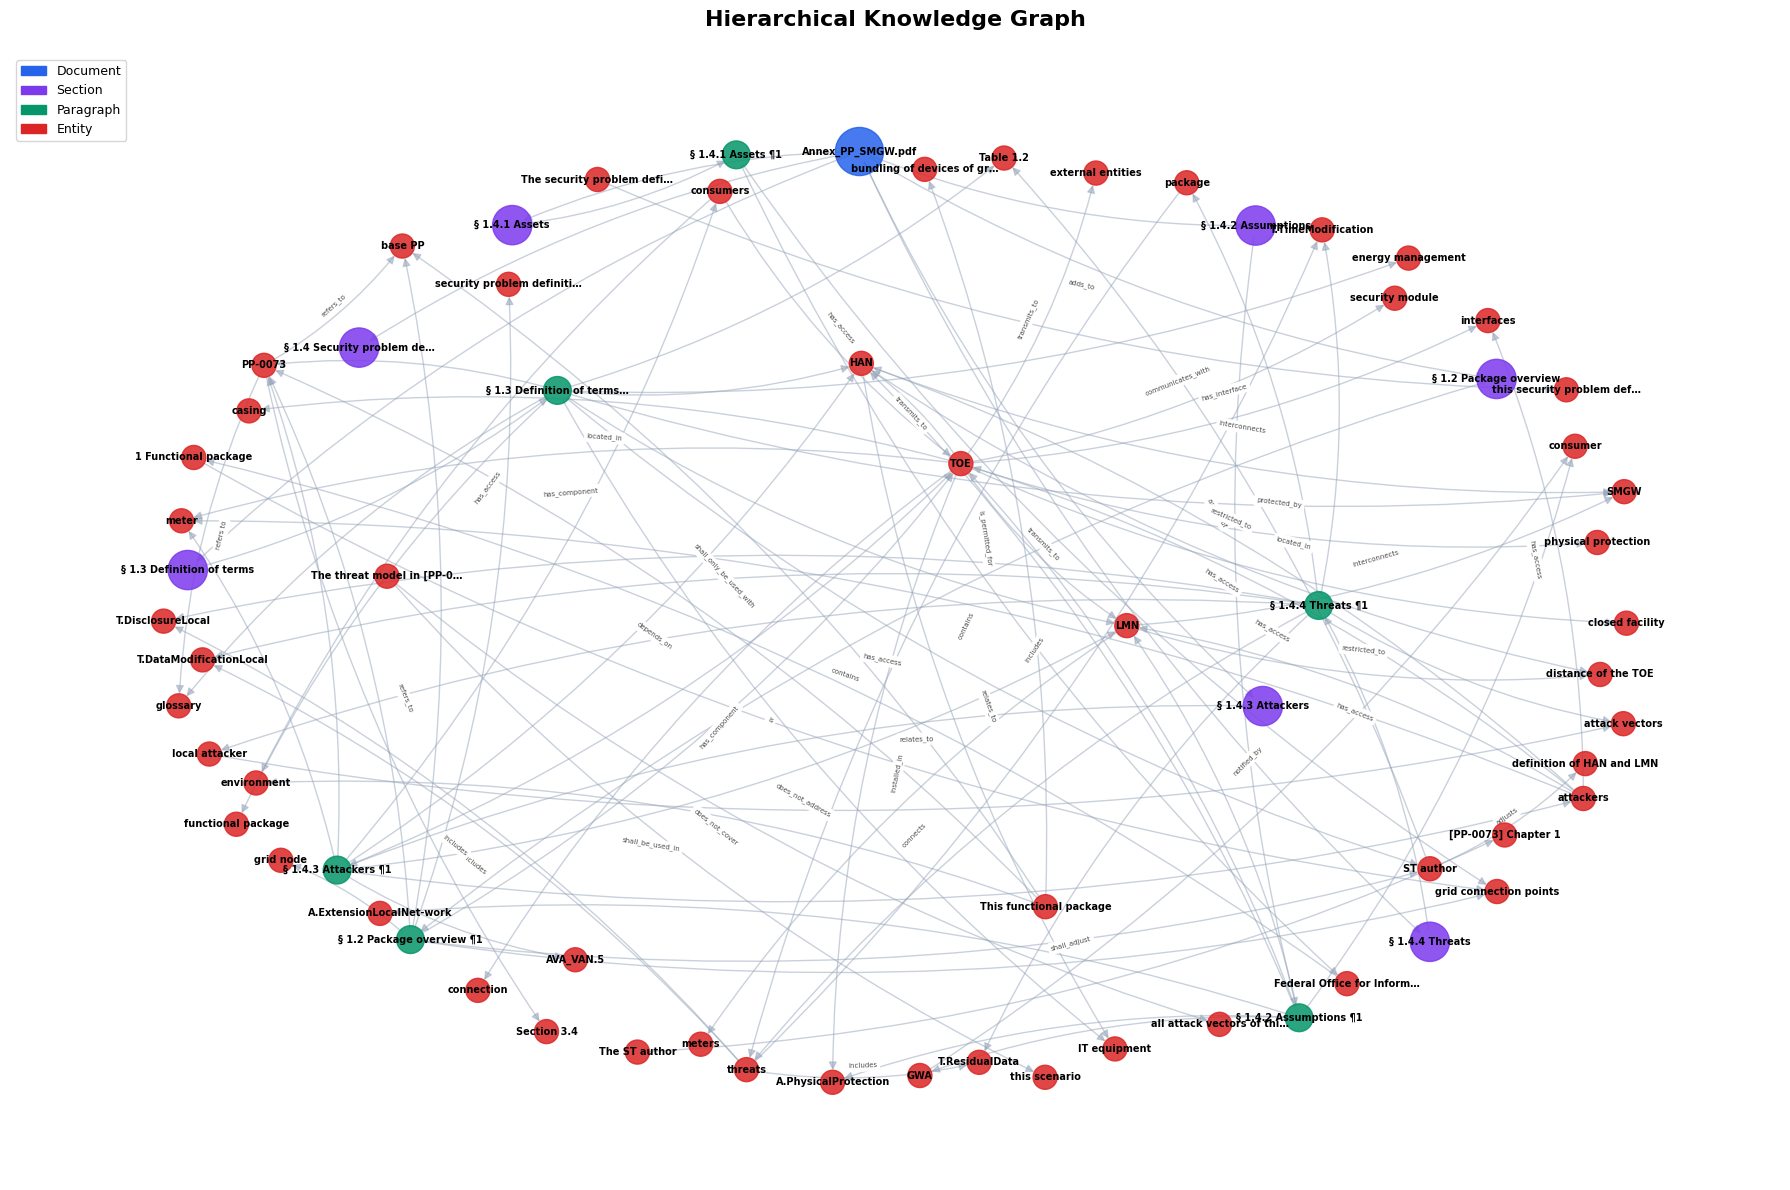


💬 Ask questions (Ctrl+C to exit):



In [ ]:
"""
Hierarchical Knowledge Graph RAG
=================================
Builds a tree-structured KG from a PDF:

    [Document]
        ├── [Section]
        │       ├── [Paragraph]
        │       │       ├── (Entity A)
        │       │       └── (Entity B) ──rel──▶ (Entity A)
        │       └── [Paragraph]
        └── [Section]

Setup:
  pip install groq pymupdf networkx matplotlib
  export GROQ_API_KEY=your-key

Usage:
  python kg_rag.py my_document.pdf
  python kg_rag.py my_document.pdf "What is the role of X?"
"""

import json, os, re, sys, textwrap
import fitz  # pymupdf
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from groq import Groq

# ── Config ──────────────────────────────────────────────────────────────
MODEL = "llama-3.1-8b-instant"
client = Groq(api_key=api_key)


def chat(system: str, user: str) -> str:
    """Simple wrapper around Groq chat completions."""
    resp = client.chat.completions.create(
        model=MODEL,
        temperature=0,
        messages=[
            {"role": "system", "content": system},
            {"role": "user", "content": user},
        ],
    )
    return resp.choices[0].message.content


# ── 1. Parse PDF into sections & paragraphs ─────────────────────────────
def parse_pdf(text) -> dict:
    """Extract text from PDF and split into sections → paragraphs."""
    full_text = sample_text

    # Try to split on numbered headings (1. Introduction, 2.1 Scope, etc.)
    section_pattern = r"(?=\n\s*\d+\.[\d.]*\s+[A-ZÄÖÜ])"
    raw_sections = re.split(section_pattern, full_text)

    sections = {}
    for i, sec in enumerate(raw_sections):
        sec = sec.strip()
        if not sec:
            continue

        # Extract section title from first line
        lines = sec.split("\n", 1)
        title = lines[0].strip()[:80] or f"Section {i}"
        body = lines[1].strip() if len(lines) > 1 else ""

        # Split into paragraphs (double newline or 100+ word blocks)
        paragraphs = [p.strip() for p in re.split(r"\n\s*\n", body) if p.strip()]
        if not paragraphs:
            paragraphs = [body] if body else []

        sections[title] = paragraphs

    # Fallback: if no sections found, treat every ~500 chars as a paragraph
    if not sections or (len(sections) == 1 and "" in sections):
        chunks = textwrap.wrap(full_text, 500, break_long_words=False)
        sections = {"Document": chunks}

    return sections


# ── 2. Extract entities & relations via LLM ──────────────────────────────
EXTRACT_PROMPT = """\
Extract entities and relationships from this text.
Return ONLY valid JSON — no markdown, no explanation.

Format:
{
  "entities": ["Entity1", "Entity2"],
  "relations": [
    {"source": "Entity1", "relation": "relates_to", "target": "Entity2"}
  ]
}

If no entities found, return: {"entities": [], "relations": []}

Text:
"""


def extract_from_paragraph(text: str) -> dict:
    """Ask LLM to extract entities and relations from one paragraph."""
    if len(text.strip()) < 20:
        return {"entities": [], "relations": []}

    # Truncate long paragraphs to stay within context
    text = text[:1500]

    raw = chat("You are an entity extraction engine. Return only JSON.",
               EXTRACT_PROMPT + text)

    try:
        # Clean markdown fences if present
        raw = raw.strip()
        raw = re.sub(r"^```(?:json)?|```$", "", raw, flags=re.MULTILINE).strip()
        data = json.loads(raw)
        return {
            "entities": data.get("entities", []),
            "relations": data.get("relations", []),
        }
    except (json.JSONDecodeError, AttributeError):
        return {"entities": [], "relations": []}


# ── 3. Build hierarchical graph ──────────────────────────────────────────
def build_graph(pdf_path: str) -> nx.DiGraph:
    """Parse PDF → extract entities → build hierarchical KG."""
    G = nx.DiGraph()
    sections = parse_pdf(pdf_path)
    doc_name = os.path.basename(pdf_path)

    # Root node
    G.add_node(doc_name, type="document")

    print(f"\n📄 Parsed {len(sections)} section(s)")

    for sec_title, paragraphs in sections.items():
        # Section node
        sec_id = f"§ {sec_title}"
        G.add_node(sec_id, type="section")
        G.add_edge(doc_name, sec_id, relation="has_section")

        for j, para in enumerate(paragraphs[:10]):  # cap paragraphs per section
            # Paragraph node
            para_id = f"{sec_id} ¶{j+1}"
            preview = para[:80].replace("\n", " ") + "..."
            G.add_node(para_id, type="paragraph", text=para, preview=preview)
            G.add_edge(sec_id, para_id, relation="has_paragraph")

            # Extract entities
            print(f"  🔍 {sec_id} ¶{j+1} — extracting...")
            extracted = extract_from_paragraph(para)

            for ent in extracted["entities"]:
                ent = ent.strip()[:60]
                if not ent:
                    continue
                G.add_node(ent, type="entity")
                G.add_edge(para_id, ent, relation="mentions")

            for rel in extracted["relations"]:
                src = rel.get("source", "").strip()[:60]
                tgt = rel.get("target", "").strip()[:60]
                r = rel.get("relation", "related_to")
                if src and tgt:
                    G.add_node(src, type="entity")
                    G.add_node(tgt, type="entity")
                    G.add_edge(src, tgt, relation=r)

    print(f"\n✅ Graph built: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    return G


# ── 4. Plot the graph ────────────────────────────────────────────────────
def plot_graph(G: nx.DiGraph, output: str = "kg_graph.png"):
    """Visualize the hierarchical knowledge graph."""
    plt.figure(figsize=(18, 12))
    plt.title("Hierarchical Knowledge Graph", fontsize=16, fontweight="bold", pad=20)

    # Color by node type
    color_map = {
        "document":  "#2563eb",
        "section":   "#7c3aed",
        "paragraph": "#059669",
        "entity":    "#dc2626",
    }
    size_map = {
        "document": 1200,
        "section": 800,
        "paragraph": 400,
        "entity": 300,
    }

    colors = [color_map.get(G.nodes[n].get("type", "entity"), "#888") for n in G]
    sizes = [size_map.get(G.nodes[n].get("type", "entity"), 300) for n in G]

    # Layout — hierarchical-ish via spring with the doc node fixed
    pos = nx.spring_layout(G, k=2.5, iterations=80, seed=42)

    # Draw
    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=sizes, alpha=0.85)
    nx.draw_networkx_edges(G, pos, edge_color="#94a3b8", arrows=True,
                           arrowsize=12, alpha=0.5, connectionstyle="arc3,rad=0.1")

    # Labels: shorten long names
    labels = {n: (n[:25] + "…" if len(n) > 25 else n) for n in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels, font_size=7, font_weight="bold")

    # Edge labels (relations)
    edge_labels = {(u, v): d.get("relation", "")
                   for u, v, d in G.edges(data=True)
                   if d.get("relation") not in ("has_section", "has_paragraph", "mentions")}
    nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=5, alpha=0.7)

    # Legend
    patches = [mpatches.Patch(color=c, label=t.title()) for t, c in color_map.items()]
    plt.legend(handles=patches, loc="upper left", fontsize=9)

    plt.axis("off")
    plt.tight_layout()
    plt.savefig(output, dpi=150, bbox_inches="tight")
    print(f"📊 Graph saved to {output}")
    plt.show()


# ── 5. RAG Query ─────────────────────────────────────────────────────────
def query_graph(G: nx.DiGraph, question: str) -> str:
    """Retrieve relevant paragraphs from the graph and answer."""

    # Find entity nodes that are textually close to the question
    q_lower = question.lower()
    relevant_paragraphs = []

    # Simple keyword match against entity names
    matched_entities = [
        n for n in G.nodes()
        if G.nodes[n].get("type") == "entity"
        and any(word in n.lower() for word in q_lower.split() if len(word) > 3)
    ]

    # Walk up from matched entities → paragraph → get text
    for ent in matched_entities:
        for pred in G.predecessors(ent):
            text = G.nodes[pred].get("text", "")
            if text and text not in relevant_paragraphs:
                relevant_paragraphs.append(text)

    # Fallback: if no entity matched, grab all paragraph texts
    if not relevant_paragraphs:
        relevant_paragraphs = [
            G.nodes[n].get("text", "")
            for n in G.nodes()
            if G.nodes[n].get("type") == "paragraph" and G.nodes[n].get("text")
        ]

    # Cap context
    context = "\n\n---\n\n".join(relevant_paragraphs[:8])

    answer = chat(
        "Answer the question using ONLY the provided context. "
        "If the answer isn't in the context, say so.",
        f"Context:\n{context}\n\nQuestion: {question}",
    )
    return answer


# ── Main ──────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    pdf = "/Users/pranavk/Desktop/HiWi/RAG/Efficient-and-Robust-Information_Retrieval-AES/pdfs/Annex_PP_SMGW.pdf"
    question = sys.argv[2] if len(sys.argv) > 2 else None

    if not pdf:
        sys.exit("Usage: python kg_rag.py <file.pdf> [question]")

    # Build graph
    G = build_graph(pdf)

    # Plot it
    plot_graph(G)

    # Query
    if question:
        print(f"\n❓ {question}")
        answer = query_graph(G, question)
        print(f"\n💬 {answer}")
    else:
        # Interactive mode
        print("\n💬 Ask questions (Ctrl+C to exit):\n")
        while True:
            try:
                q = input(">>> ").strip()
                if not q:
                    continue
                answer = query_graph(G, q)
                print(f"\n{answer}\n")
            except (KeyboardInterrupt, EOFError):
                print("\nBye!")
                break